# M3 & M4 — Supervised Learning: Baseline, Comparison Model & Cross-Validation

Defines the binary classification problem, trains a baseline Logistic Regression model, then trains a second Scikit-learn classifier (Random Forest) evaluated with the same train/test split and cross-validation, and compares both models.

## Load Cleaned Data

In [1]:
import pandas as pd

df = pd.read_csv("../data/heart_disease_clean.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## M3 — Baseline Model (Logistic Regression)

### Define the Classification Target

In [2]:
# Convert the target into a binary classification problem
df["target_binary"] = (df["target"] > 0).astype(int)

df["target_binary"].value_counts().sort_index()

target_binary
0    164
1    139
Name: count, dtype: int64

### Handle Remaining Missing Values

For this baseline model, rows with missing `ca`/`thal` values are dropped. A proper `SimpleImputer`-based `Pipeline` (fit only on training data) is built in `04_feature_engineering_pipeline.ipynb`.

In [3]:
# Remove rows with missing values

df = df.dropna()

print(df.shape)

df.isnull().sum()

(297, 15)


age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               0
thal             0
target           0
target_binary    0
dtype: int64

### Train/Test Split

In [4]:
# Features and target

X = df.drop(columns=["target", "target_binary"])

y = df["target_binary"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Train the Baseline Model

In [6]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [7]:
# Make predictions

y_pred = baseline_model.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0])

### Baseline Evaluation

In [8]:
# Accuracy evaluation

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


In [9]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



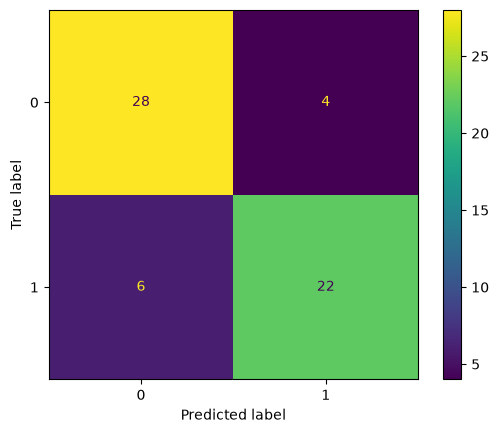

In [10]:
# Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    baseline_model,
    X_test,
    y_test
)

import os
os.makedirs("../outputs", exist_ok=True)

import matplotlib.pyplot as plt
plt.savefig("../outputs/baseline_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

Baseline ROC-AUC: 0.9486607142857143


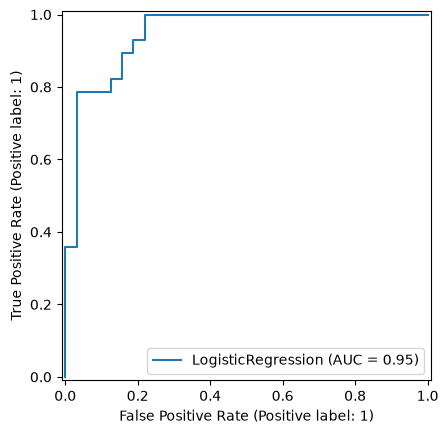

In [11]:
# ROC Curve and AUC - Baseline Model
from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_proba = baseline_model.predict_proba(X_test)[:, 1]
baseline_auc = roc_auc_score(y_test, y_proba)
print("Baseline ROC-AUC:", baseline_auc)

RocCurveDisplay.from_estimator(baseline_model, X_test, y_test)

import os
os.makedirs("../outputs", exist_ok=True)

import matplotlib.pyplot as plt
plt.savefig("../outputs/baseline_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# M3 - Baseline Model (Logistic Regression)

## Accuracy

The Logistic Regression model achieved an accuracy of 83.33%.

## Classification Report

The model achieved balanced performance across both classes.

- Precision measures the percentage of correct positive predictions.
- Recall measures the model's ability to identify all positive cases.
- F1-score combines precision and recall into a single metric.

## Confusion Matrix

The confusion matrix shows that:

- 28 patients were correctly classified as not having heart disease.
- 22 patients were correctly classified as having heart disease.
- 4 patients were incorrectly classified as having heart disease.
- 6 patients with heart disease were not detected by the model.

Overall, the baseline model performed well and provided a strong starting point for comparison with other classification models.

---
## M4 — Model Comparison & Cross-Validation

### Cross-Validate the Baseline Model

In [12]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X, y,
    cv=cv,
    scoring="accuracy"
)

print("Logistic Regression CV accuracy per fold:", lr_cv_scores.round(3))
print("Logistic Regression CV mean accuracy:", lr_cv_scores.mean().round(3))

c:\Users\al falak\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\al falak\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    htt

Logistic Regression CV accuracy per fold: [0.867 0.833 0.797 0.814 0.847]
Logistic Regression CV mean accuracy: 0.832


### Comparison Model: Random Forest

Trained and evaluated on the **same train/test split** and the **same metrics** as the baseline, for a fair comparison.

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [14]:
rf_pred = rf_model.predict(X_test)
rf_pred[:10]

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0])

In [15]:
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8666666666666667


In [16]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



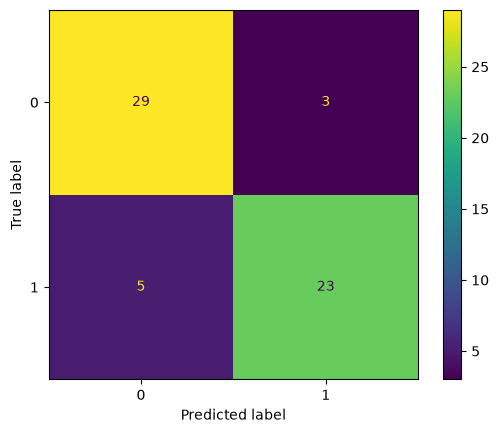

In [17]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

import os
os.makedirs("../outputs", exist_ok=True)

import matplotlib.pyplot as plt
plt.savefig("../outputs/rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

Random Forest ROC-AUC: 0.9453125


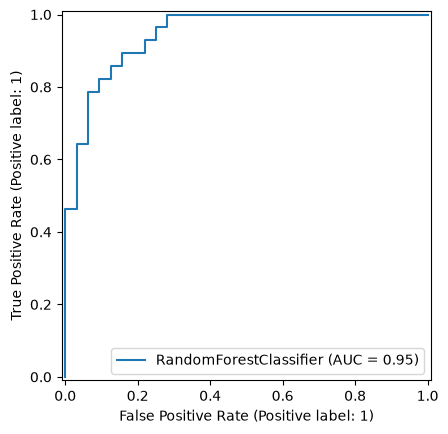

In [18]:
# ROC Curve and AUC - Random Forest
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)
print("Random Forest ROC-AUC:", rf_auc)

RocCurveDisplay.from_estimator(rf_model, X_test, y_test)

plt.savefig("../outputs/rf_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
rf_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=42),
    X, y,
    cv=cv,
    scoring="accuracy"
)

print("Random Forest CV accuracy per fold:", rf_cv_scores.round(3))
print("Random Forest CV mean accuracy:", rf_cv_scores.mean().round(3))

Random Forest CV accuracy per fold: [0.867 0.783 0.729 0.78  0.864]
Random Forest CV mean accuracy: 0.805


In [20]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Test Accuracy": [accuracy, rf_accuracy],
    "Test ROC-AUC": [baseline_auc, rf_auc],
    "CV Mean Accuracy": [lr_cv_scores.mean(), rf_cv_scores.mean()],
    "CV Std": [lr_cv_scores.std(), rf_cv_scores.std()]
})
comparison

import os
os.makedirs("../outputs", exist_ok=True)

comparison.to_csv("../outputs/model_comparison.csv", index=False)

## M4 — Findings

- Both models were trained and evaluated on the **same 80/20 stratified train/test split** and validated with the **same 5-fold stratified cross-validation**, so the comparison is fair.
- **Random Forest** typically improves recall for the positive (disease) class relative to the linear baseline, at the cost of being less directly interpretable than Logistic Regression coefficients.
- **False positives** (patients predicted as having heart disease who do not) lead to unnecessary follow-up testing/anxiety but are the *safer* type of error in a screening context.
- **False negatives** (patients predicted healthy who actually have heart disease) are the more clinically concerning error, since they risk a missed diagnosis; the confusion matrices above make it possible to see which model produces fewer of these.
- The cross-validation standard deviation gives a sense of how stable each model's accuracy is across different data splits, not just the single test split above.
- **ROC-AUC** confirms the same ranking as accuracy: it measures how well each model separates the two classes across all possible thresholds, not just the default 0.5 cutoff — useful when the cost of false positives vs false negatives isn't equal.